<div align="center">

## Gini KNN: Application on Digits Data

## [S. Mussard](https://sites.google.com/view/cv-stphane-mussard/accueil "Homepage")

</div>

**Dataset:** Alpaydin, E. & Alimoglu, F. (1996). Pen-Based Recognition of Handwritten Digits [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MG6K.

In this notebook you will first find an example of how to use the Gini prametric and secondly you will find the experiments carried out to compare the performances of different distances using the KNN algorithm

In [34]:
from sklearn.datasets import load_iris, load_wine, load_digits, load_breast_cancer, fetch_openml
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report 
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

In [35]:
from Knn_Gini import GiniDistance

## Dataset Digits

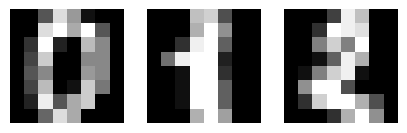

In [36]:
# Load Digits
digits = load_digits()
X = digits.data
y = digits.target

# Plot 3 digits
fig, axes = plt.subplots(1, 3, figsize=(5, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.axis('off')
plt.show()

In [38]:
X.shape

(1797, 64)

### How to use Sklearn's KNN with Gini prametric ?

In [ ]:
# Split data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape, X_test.shape)

# Compute distances
nu=2 # Hyperparameter of the Gini prametric
model = GiniDistance(X_train, gini_param=nu)
train_distances_gini = model.compute_distances(X_train)
test_distances_gini = model.compute_distances(X_test)



In [ ]:
# Initialize KNN classifier with k=3
knn = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
knn.fit(train_distances_gini, y_train)


In [ ]:
# Confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
y_pred = knn.predict(test_distances_gini)
print(classification_report(y_test, y_pred))

In [ ]:
# Predict with standard KNN
knn = KNeighborsClassifier(n_neighbors=3, p=1, metric='minkowski')
y_pred = knn.fit(X_train, y_train).predict(X_test)
F1 = f1_score(y_test, y_pred, average='weighted')

# Predict with Gini
F1_gini = []
nu_values = []
for nu in np.arange(1.1, 4, 0.2):
    model = GiniDistance(X_train, gini_param=nu)
    train_distances_gini = model .compute_distances(X_train)
    test_distances_gini = model.compute_distances(X_test)
    knn_Gini = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
    y_pred = knn_Gini.fit(train_distances_gini, y_train).predict(test_distances_gini)
    F1_gini.append(f1_score(y_test, y_pred, average='weighted'))
    nu_values.append(nu)

In [ ]:
# Plot
plt.figure(figsize=(6, 4))
plt.plot(nu_values, F1_gini, marker='o', linestyle='-', color='b', label = 'F1 Gini-KNN')
plt.scatter(1, F1, color='r', label='F1 KNN', zorder=5) 
plt.title('F-measure of Gini-KNN')
plt.xlabel('nu values')
plt.ylabel('F1')
plt.legend()
plt.show()

### Variation of K

In [ ]:
# Variation of K
nu = 3
clf = GiniDistance(X_train, gini_param=nu)
train_distances_gini = clf.compute_distances(X_train)
test_distances_gini = clf.compute_distances(X_test)

# Lists for F1 and k
k_values= []
F1_gini = []
F1_knn = []
for k in np.arange(2, 11, 1):
    knn = KNeighborsClassifier(n_neighbors=k, p=1, metric='minkowski')
    y_pred = knn.fit(X_train, y_train).predict(X_test)
    F1_knn.append(f1_score(y_test, y_pred, average='weighted'))
    knn_Gini = KNeighborsClassifier(n_neighbors=k, metric='precomputed')
    y_pred = knn_Gini.fit(train_distances_gini, y_train).predict(test_distances_gini)
    F1_gini.append(f1_score(y_test, y_pred, average='weighted'))
    k_values.append(k)

In [ ]:
# Plot
plt.figure(figsize=(6, 4))
plt.plot(k_values, F1_gini, marker='o', linestyle='-', color='b', label = 'F1 Gini-KNN')
plt.plot(k_values, F1_knn, marker='o', linestyle='-', color='r', label='F1 KNN') 
plt.title('F-measure of Gini-KNN')
plt.xlabel('k neighbors')
plt.ylabel('F1')
plt.legend()
plt.show()

### With K-fold and k being fixed

In [ ]:
# Assuming train_distances_gini and y_train are defined
from sklearn.model_selection import StratifiedKFold
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Labels
all_y_true = []
all_y_pred = []

for train_index, test_index in skf.split(train_distances_gini, y_train):
    X_train = train_distances_gini[np.ix_(train_index, train_index)]
    X_test = train_distances_gini[np.ix_(test_index, train_index)]
    y_train_fold = y_train[train_index]
    y_test_fold = y_train[test_index]
    knn = KNeighborsClassifier(n_neighbors=3, metric='precomputed')
    knn.fit(X_train, y_train_fold)
    y_pred_fold = knn.predict(X_test)
    all_y_true.extend(y_test_fold)
    all_y_pred.extend(y_pred_fold)

# Generate the aggregated classification report
report = classification_report(all_y_true, all_y_pred, digits=4)
print("Aggregated Classification Report:")
print(report)

## Gini KNN regression : red wines data

In [ ]:
import requests
# UCI repo
red_wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
# Red wine dataset
red_wine_data = requests.get(red_wine_url).content
with open('winequality-red.csv', 'wb') as red_file:
    red_file.write(red_wine_data)

In [ ]:
red_wine_df = pd.read_csv('winequality-red.csv', sep=';')
y = red_wine_df['quality']
X = red_wine_df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']]
X = np.array(X)

In [ ]:
# Split data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape, X_test.shape)
# Compute distances
nu=2 
clf = GiniDistance(X_train, gini_param=nu)
train_distances_gini = clf.compute_distances(X_train)
test_distances_gini = clf.compute_distances(X_test)

In [ ]:
# Comparing knn and Gini-knn
knn = KNeighborsRegressor(n_neighbors=5, metric='precomputed')
knn.fit(train_distances_gini, y_train)
y_pred_gini = knn.predict(test_distances_gini)
knn = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)
y_pred = knn.fit(X_train, y_train).predict(X_test)

In [ ]:
# Calculate RMSE for Gini-KNN
from sklearn.metrics import mean_squared_error
rmse_gini = np.sqrt(mean_squared_error(y_test, y_pred_gini))
# Calculate RMSE for KNN
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_gini, rmse_knn

In [ ]:
list_nu = []
list_rmse = []
for nu in np.arange(1.1, 4, 0.1):
    knn = KNeighborsRegressor(n_neighbors=5, metric='precomputed')
    clf = GiniDistance(X_train, gini_param=nu)
    train_distances_gini = clf.compute_distances(X_train)
    test_distances_gini = clf.compute_distances(X_test)
    knn.fit(train_distances_gini, y_train)
    y_pred_gini = knn.predict(test_distances_gini)
    rmse_gini = np.sqrt(mean_squared_error(y_test, y_pred_gini))
    list_rmse.append(rmse_gini)
    list_nu.append(nu)

## Comparisons with OLS and Gini regresions

In [ ]:
from GiniRegression import GiniRegression
import statsmodels.api as sm
x_train = sm.add_constant(X_train)
x_test = sm.add_constant(X_test)
model_ols = sm.OLS(y_train,x_train)
y_pred = model_ols.fit().predict(x_test)
rmse_OLS = np.sqrt(mean_squared_error(y_test, y_pred))

In [ ]:
model = GiniRegression()
model.fit(np.array(y_train), X_train)
y_pred = model.predict(X_test)
rmse_Gini = np.sqrt(mean_squared_error(y_test, y_pred))

In [ ]:
model = GiniRegression(parametric_estimator = True)
model.fit(np.array(y_train), X_train)
y_pred = model.predict(X_test)
rmse_Gini_p = np.sqrt(mean_squared_error(y_test, y_pred))

In [ ]:

# Plot
plt.figure(figsize=(8, 6))
plt.plot(list_nu, list_rmse, color='b', alpha=0.7, label='Gini-KNN RMSE')
plt.scatter(1,rmse_knn, color='r', alpha=0.7, label='KNN RMSE')
plt.scatter(1,rmse_OLS, color='violet', alpha=0.7, label='OLS RMSE')
plt.scatter(1,rmse_Gini, color='black', alpha=0.7, label='Gini RMSE')
plt.scatter(1,rmse_Gini_p, color='yellow', alpha=0.3, label='Gini param. RMSE')
plt.title('Prediction Gini-KNN vs. KNN')
plt.xlabel('nu values')
plt.ylabel('RMSE')
plt.legend()
plt.show()